# NOAA Weather Time-Series Case Study — Bengaluru (VOBL)
**Global Summary of the Day (GSOD)** · Station `43295099999` · 2019–2024

Daily temperature & precipitation: trend, seasonality, stationarity, ACF/PACF,
and short-term forecasting with persistence, LSTM, and Transformer models.
All outputs are reproducible (seed = 42).

In [1]:
import os, sys, warnings, json
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import models as M, statistical_analysis as S
from preprocessing import build_processed
M.set_seed(42)
pd.set_option("display.width", 120)

## 1. Research Problem
**How do temporal dependence, trend, and seasonal patterns influence daily mean temperature at the Bengaluru NOAA station, and to what extent can historical observations forecast next-day temperature using LSTM and Transformer models?** Secondary: how does precipitation differ from temperature in variability, stationarity, and autocorrelation? Observational data — no causal claims. Primary variable: daily mean temperature (°C); secondary: precipitation (mm); objective: one-step (t+1) temperature forecast.

## 2. Dataset Understanding

In [2]:
df = build_processed()
print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "->", df.index.max().date())
df.head()

Shape: (2192, 10)
Date range: 2019-01-01 -> 2024-12-31


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,temperature_c,tmax_c,tmin_c,precipitation_mm,temperature_c_interp
date,,,,,,,,,,
2019-01-01,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,20.277778,27.611111,14.000000,NaN,20.277778
2019-01-02,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,19.888889,28.111111,12.388889,NaN,19.888889
2019-01-03,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,20.222222,27.611111,13.111111,NaN,20.222222
2019-01-04,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,20.833333,28.500000,13.277778,NaN,20.833333
2019-01-05,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,20.388889,28.611111,13.611111,NaN,20.388889


In [3]:
df.tail()

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,temperature_c,tmax_c,tmin_c,precipitation_mm,temperature_c_interp
date,,,,,,,,,,
2024-12-27,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,21.277778,24.722222,19.277778,1.016,21.277778
2024-12-28,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,22.055556,26.222222,17.888889,NaN,22.055556
2024-12-29,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,22.444444,27.388889,17.388889,NaN,22.444444
2024-12-30,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,21.888889,28.222222,17.777778,NaN,21.888889
2024-12-31,4.329510e+10,"BANGALORE, IN",12.966667,77.583333,921.0,23.055556,28.611111,16.611111,NaN,23.055556


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2192 entries, 2019-01-01 to 2024-12-31
Freq: D
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   STATION               2192 non-null   float64
 1   NAME                  2192 non-null   object 
 2   LATITUDE              2192 non-null   float64
 3   LONGITUDE             2192 non-null   float64
 4   ELEVATION             2192 non-null   float64
 5   temperature_c         2170 non-null   float64
 6   tmax_c                2170 non-null   float64
 7   tmin_c                2170 non-null   float64
 8   precipitation_mm      1201 non-null   float64
 9   temperature_c_interp  2192 non-null   float64
dtypes: float64(9), object(1)
memory usage: 188.4+ KB


In [5]:
print("Station:", df['NAME'].iloc[0], "| id 43295099999 | ",
      df['LATITUDE'].iloc[0], df['LONGITUDE'].iloc[0], "elev", df['ELEVATION'].iloc[0], "m")
df[['temperature_c','tmax_c','tmin_c','precipitation_mm']].describe()

Station: BANGALORE, IN | id 43295099999 |  12.9666666 77.5833333 elev 921.0 m


,temperature_c,tmax_c,tmin_c,precipitation_mm
count,2170.000000,2170.000000,2170.000000,1201.000000
mean,24.212775,30.017204,20.016283,6.319122
std,2.197168,2.969414,2.080299,13.753145
min,18.388889,20.777778,12.277778,0.000000
25%,22.666667,28.000000,19.000000,0.000000
50%,23.888889,29.500000,20.388889,0.508000
75%,25.500000,32.000000,21.222222,5.080000
max,31.611111,38.611111,25.222222,131.572000


In [6]:
print("Missing temperature_c :", int(df['temperature_c'].isna().sum()))
print("Missing precipitation_mm:", int(df['precipitation_mm'].isna().sum()),
      "(dry-season 'I'-flag non-measurements kept as NaN)")
print("Duplicate dates:", int(df.index.duplicated().sum()))

Missing temperature_c : 22
Missing precipitation_mm: 991 (dry-season 'I'-flag non-measurements kept as NaN)
Duplicate dates: 0


GSOD native units are °F (temperature, sentinel 9999.9) and inches (precipitation, sentinel 99.99), converted to °C and mm. `PRCP` flag `I` means the day was not actually measured, so those 0.00 values are treated as **missing**, not real zeros.

## 3. Data Cleaning and Preparation
Handled in `src/preprocessing.py`: date parsing, chronological sort, duplicate removal, reindex to a continuous daily calendar, sentinel→NaN, `PRCP` flag semantics, °F→°C and inch→mm conversion, and ≤3-day time interpolation of temperature (`temperature_c_interp`) for continuous-series methods. Precipitation is **not** interpolated (intermittent).

In [7]:
temp = df['temperature_c_interp'].copy()
temp_raw = df['temperature_c'].copy()
prcp = df['precipitation_mm'].copy()

## 4. Time-Series Visualization

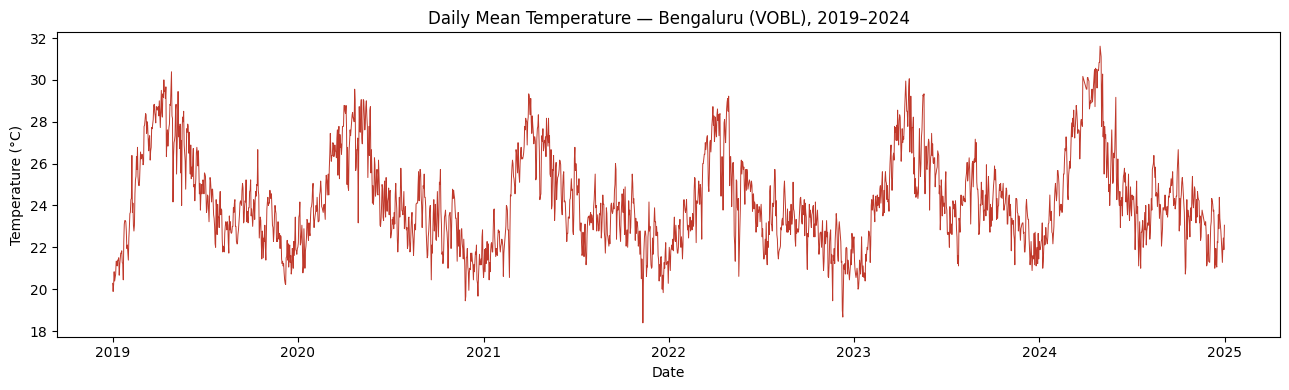

In [8]:
plt.figure(figsize=(13,4))
plt.plot(temp.index, temp.values, lw=0.7, color='#c0392b')
plt.title('Daily Mean Temperature — Bengaluru (VOBL), 2019–2024')
plt.xlabel('Date'); plt.ylabel('Temperature (°C)'); plt.tight_layout(); plt.show()

*Clear repeating annual band ~18–32 °C; pre-monsoon (Mar–May) peaks, monsoon/winter troughs; no dramatic long-term drift.*

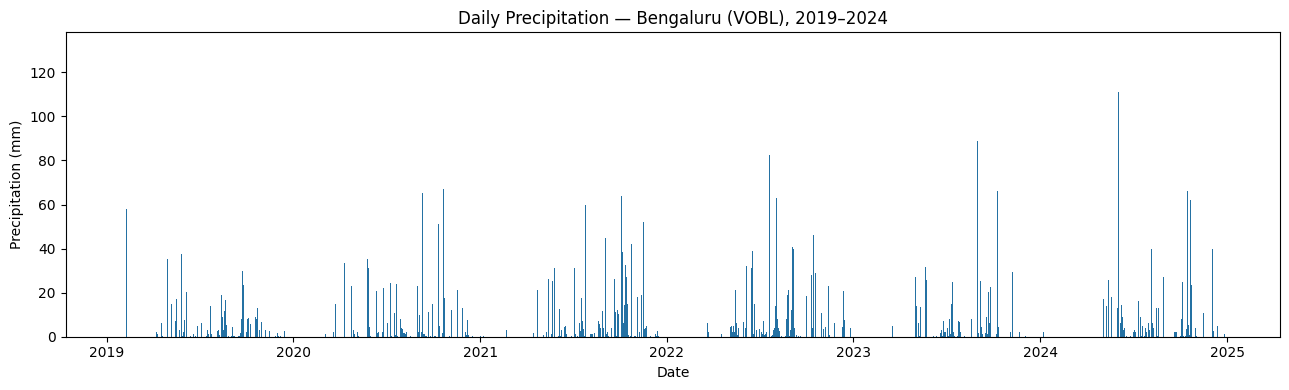

In [9]:
plt.figure(figsize=(13,4))
plt.bar(prcp.index, prcp.values, width=1.0, color='#2471a3')
plt.title('Daily Precipitation — Bengaluru (VOBL), 2019–2024')
plt.xlabel('Date'); plt.ylabel('Precipitation (mm)'); plt.tight_layout(); plt.show()

*Spiky and intermittent: long near-zero dry stretches punctuated by clustered monsoon/post-monsoon rainfall events.*

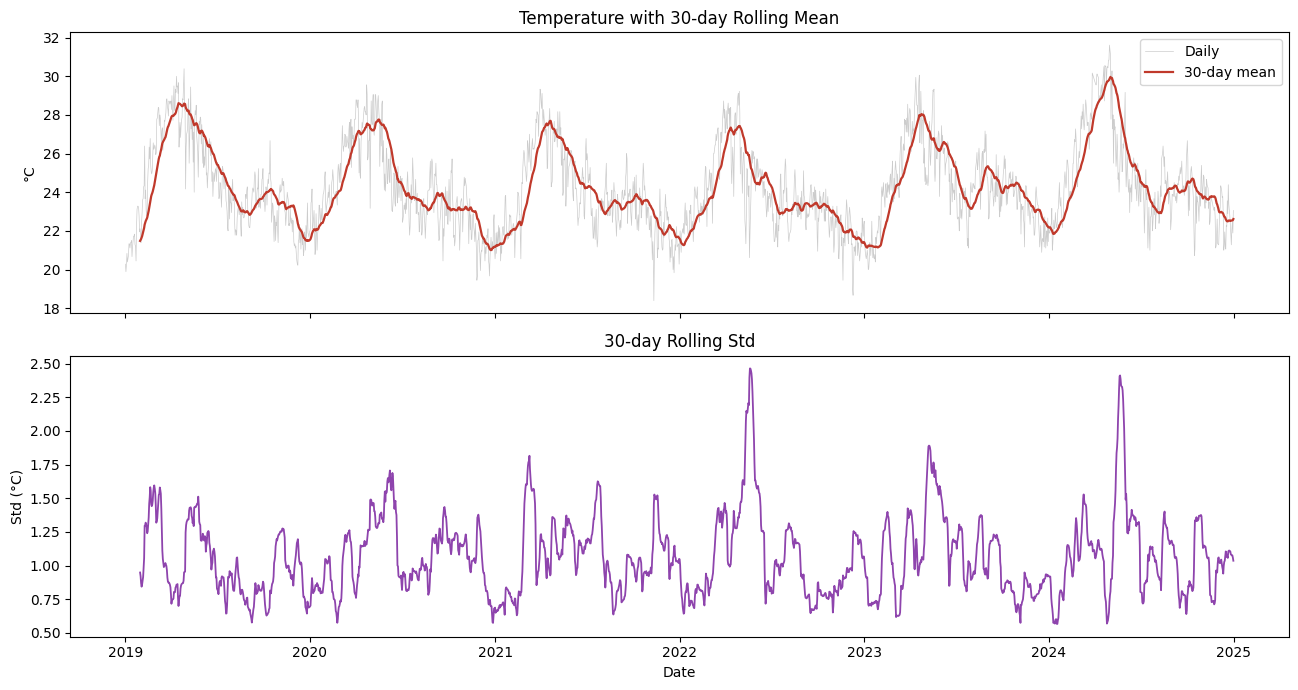

In [10]:
rm, rs = temp.rolling(30).mean(), temp.rolling(30).std()
fig, ax = plt.subplots(2,1,figsize=(13,7),sharex=True)
ax[0].plot(temp.index, temp.values, lw=0.5, alpha=0.4, color='grey', label='Daily')
ax[0].plot(rm.index, rm.values, lw=1.6, color='#c0392b', label='30-day mean')
ax[0].legend(); ax[0].set_ylabel('°C'); ax[0].set_title('Temperature with 30-day Rolling Mean')
ax[1].plot(rs.index, rs.values, lw=1.3, color='#8e44ad'); ax[1].set_ylabel('Std (°C)')
ax[1].set_title('30-day Rolling Std'); ax[1].set_xlabel('Date'); plt.tight_layout(); plt.show()

*Rolling mean traces a stable seasonal wave; rolling std is itself seasonal (wider spread in transition months) — variance is time-varying but bounded.*

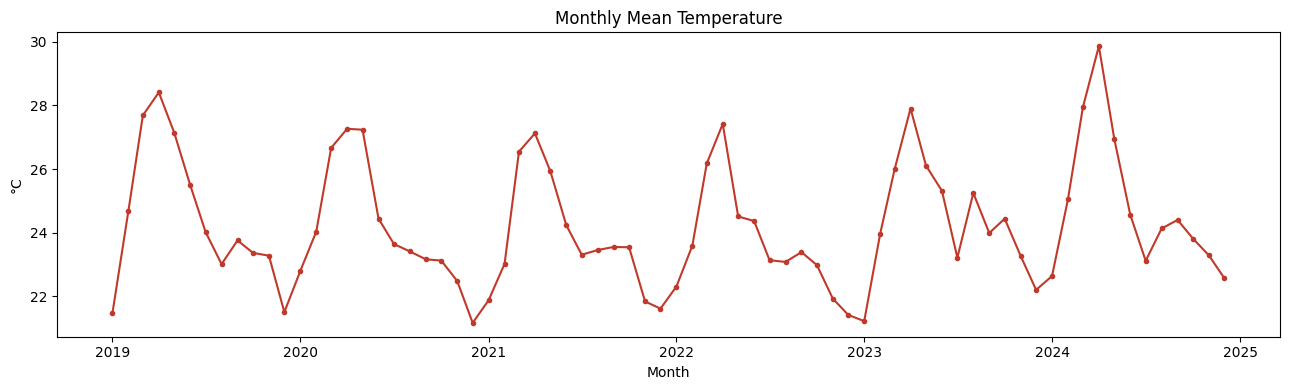

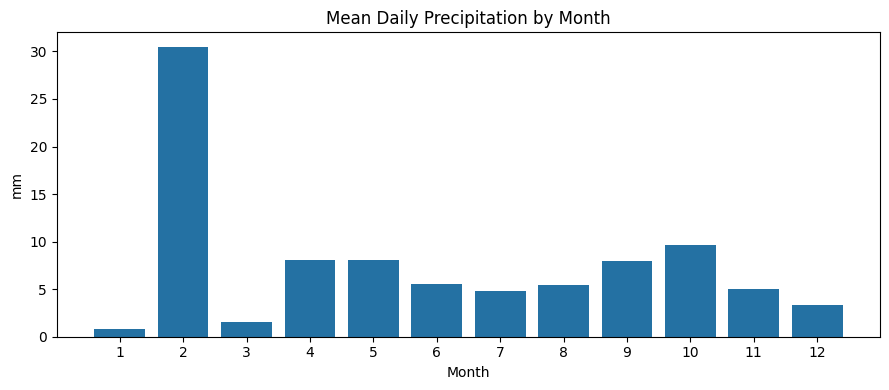

In [11]:
mt = temp.resample('MS').mean()
plt.figure(figsize=(13,4)); plt.plot(mt.index, mt.values, marker='o', ms=3, color='#c0392b')
plt.title('Monthly Mean Temperature'); plt.xlabel('Month'); plt.ylabel('°C'); plt.tight_layout(); plt.show()
clim = prcp.groupby(prcp.index.month).mean()
plt.figure(figsize=(9,4)); plt.bar(clim.index, clim.values, color='#2471a3')
plt.title('Mean Daily Precipitation by Month'); plt.xlabel('Month'); plt.ylabel('mm')
plt.xticks(range(1,13)); plt.tight_layout(); plt.show()

*Monthly means repeat the same annual cycle (Apr/May max); precipitation climatology peaks Sep–Oct, dry Dec–Feb.*

## 5. Trend and Seasonality Analysis (STL, period=365)

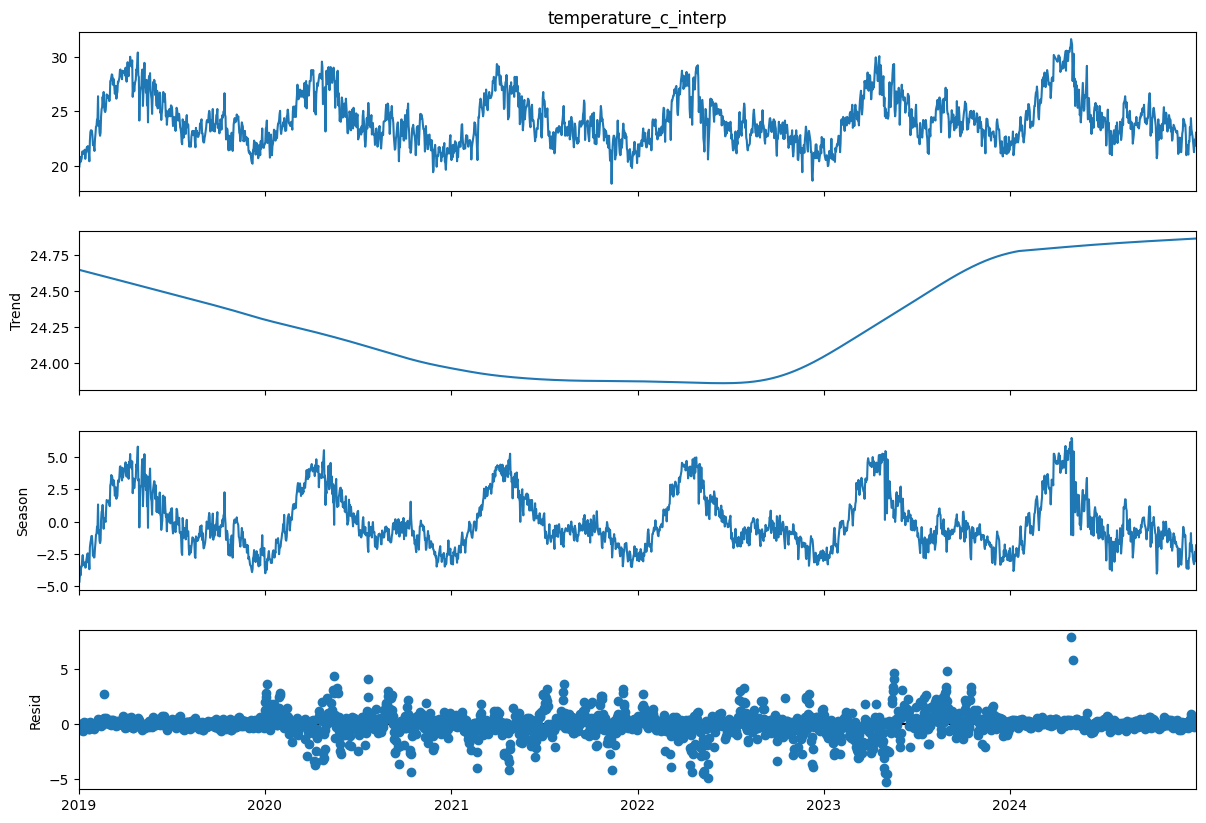

Seasonal strength: 0.789  Trend strength: 0.161
Trend: 24.65 -> 24.86 °C


In [12]:
stl = STL(temp, period=365, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(13,9); plt.show()
ss = max(0.0, 1 - stl.resid.var()/(stl.seasonal+stl.resid).var())
ts = max(0.0, 1 - stl.resid.var()/(stl.trend+stl.resid).var())
print(f'Seasonal strength: {ss:.3f}  Trend strength: {ts:.3f}')
print(f'Trend: {stl.trend.dropna().iloc[0]:.2f} -> {stl.trend.dropna().iloc[-1]:.2f} °C')

*Seasonal strength ≈ 0.79 (strong annual cycle dominates); trend strength ≈ 0.16 (weak) with mild net warming ≈ +0.21 °C over six years. Residuals small and near-zero — trend + season capture most systematic variation.*

## 6. Stationarity Analysis (ADF & KPSS)
**ADF** H0: unit root (non-stationary) → reject (p<0.05) ⇒ stationary. **KPSS** H0: stationary → fail to reject (p≥0.05) ⇒ stationary. Opposite nulls.

In [13]:
td = temp.diff().dropna()
rows = []
for name, s in [('Raw temperature', temp), ('First difference', td)]:
    a, k = S.adf_test(s), S.kpss_test(s)
    rows.append({'Series':name,'ADF stat':round(a['statistic'],3),'ADF p':round(a['p_value'],5),
                 'KPSS stat':round(k['statistic'],3),'KPSS p':k['p_value'],
                 'Conclusion':S.stationarity_conclusion(a,k)})
pd.DataFrame(rows)

,Series,ADF stat,ADF p,KPSS stat,KPSS p,Conclusion
0,Raw temperature,-4.451,0.00024,0.128,0.1,Stationary (ADF & KPSS agree)
1,First difference,-23.500,0.00000,0.039,0.1,Stationary (ADF & KPSS agree)


*Raw temperature is **stationary by both tests** — Bengaluru's bounded tropical climate is mean-reverting despite visible seasonality. Differencing keeps it stationary, so differencing is available but not required.*

## 7. ACF / PACF Analysis

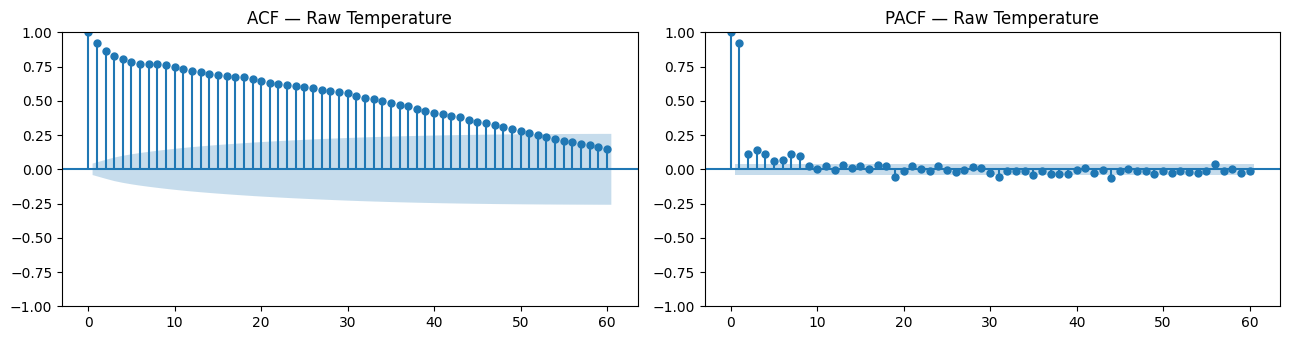

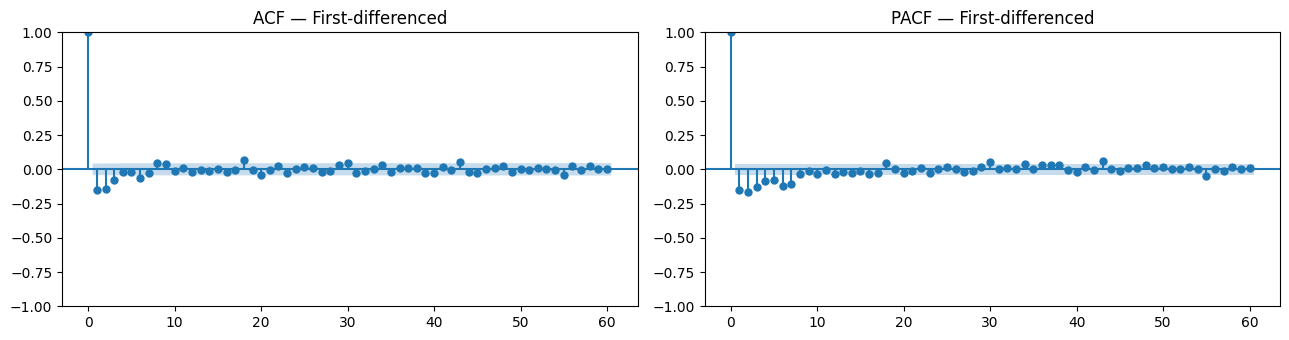

lag-1 ACF raw : 0.921
lag-1 ACF diff: -0.148
lag-365 ACF   : 0.702


In [14]:
for s, ttl in [(temp,'Raw Temperature'), (td,'First-differenced')]:
    fig, ax = plt.subplots(1,2,figsize=(13,3.5))
    plot_acf(s.dropna(), lags=60, ax=ax[0]); ax[0].set_title(f'ACF — {ttl}')
    plot_pacf(s.dropna(), lags=60, ax=ax[1], method='ywm'); ax[1].set_title(f'PACF — {ttl}')
    plt.tight_layout(); plt.show()
print('lag-1 ACF raw :', round(temp.autocorr(1),3))
print('lag-1 ACF diff:', round(td.autocorr(1),3))
print('lag-365 ACF   :', round(temp.autocorr(365),3))

*ACF measures total correlation across lags; PACF isolates a lag after removing shorter ones. Raw lag-1 = 0.921 (strong persistence); PACF cuts off after 1–2 lags (AR-like); annual echo at lag-365 = 0.702. Differencing collapses lag-1 to −0.148. → a 30-day input window covers the short memory the PACF reveals and explains why persistence is a strong baseline.*

## 8. Initial Findings and Research Hypothesis
1. Strong annual seasonality (STL 0.79), weak warming trend (+0.21 °C).
2. Temperature stationary in level (ADF p=0.0002, KPSS p=0.10).
3. Very high short-term persistence (lag-1 ACF 0.921), AR-like PACF.
4. Precipitation intermittent/right-skewed, seasonal only in aggregate.
5. Annual echo at lag-365 (ACF 0.702).

**H1:** recent-history sequence models should beat a mean forecast and may approach/beat persistence. **H0:** sequential structure gives no material gain over naive persistence at t+1. *Result (below) fails to reject H0.*

## 9. Forecasting Methodology
Target: next-day temp (°C), t+1. Chronological 70/15/15, scaler fit on train only, 30-day window, seed 42.

In [15]:
SEQ=30; vals=temp.values.astype(float); n=len(vals)
i_tr,i_va=int(n*0.7),int(n*0.85)
scaler=StandardScaler().fit(vals[:i_tr].reshape(-1,1))
scaled=scaler.transform(vals.reshape(-1,1)).ravel()
def split(a,lo,hi):
    X,y=[],[]
    for t in range(SEQ,n):
        if lo<=t<hi: X.append(a[t-SEQ:t]); y.append(a[t])
    return np.array(X)[...,None], np.array(y)
Xtr,ytr=split(scaled,SEQ,i_tr); Xva,yva=split(scaled,i_tr,i_va); Xte,yte=split(scaled,i_va,n)
inv=lambda a: scaler.inverse_transform(np.asarray(a).reshape(-1,1)).ravel()
test_dates=temp.index[i_va:n]
print('train/val/test seqs:', len(Xtr), len(Xva), len(Xte))

train/val/test seqs: 1504 329 329


## 10. Baseline

In [16]:
yt,yp=M.persistence_forecast(vals[i_va-1:n])
base={'mae':M.mae(yt,yp),'rmse':M.rmse(yt,yp),'train_time':0.0}
print('Persistence  MAE %.3f  RMSE %.3f'%(base['mae'],base['rmse']))

Persistence  MAE 0.674  RMSE 0.888


## 11. LSTM

LSTM  MAE 0.766  RMSE 0.972  (5.1s)


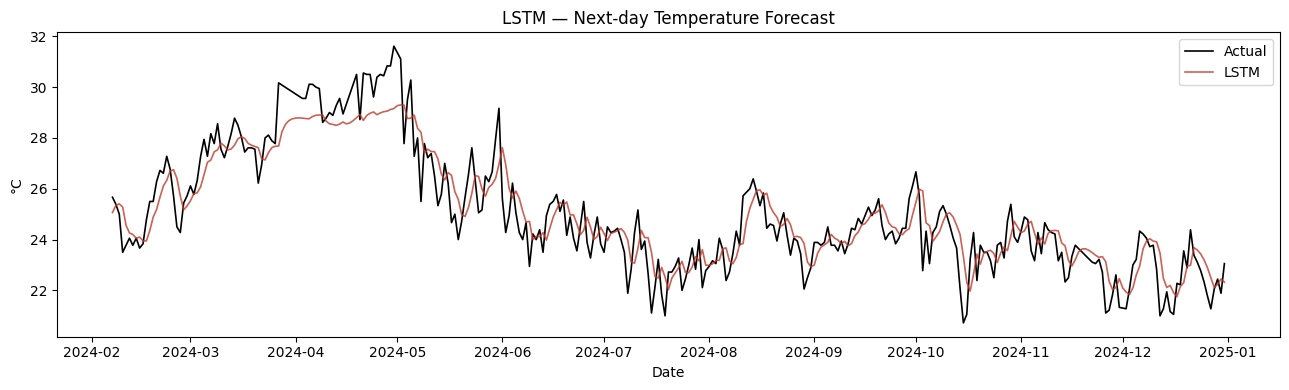

In [17]:
lstm=M.LSTMForecaster(hidden=32,layers=1)
lstm,lv,ltt=M.train_model(lstm,Xtr,ytr,Xva,yva,epochs=15,patience=3)
with torch.no_grad(): pl=inv(lstm(torch.tensor(Xte,dtype=torch.float32)).numpy())
yo=inv(yte); lstm_res={'mae':M.mae(yo,pl),'rmse':M.rmse(yo,pl),'train_time':ltt}
print('LSTM  MAE %.3f  RMSE %.3f  (%.1fs)'%(lstm_res['mae'],lstm_res['rmse'],ltt))
plt.figure(figsize=(13,4)); plt.plot(test_dates,yo,color='black',lw=1.2,label='Actual')
plt.plot(test_dates,pl,color='#c0392b',lw=1.2,alpha=0.8,label='LSTM')
plt.title('LSTM — Next-day Temperature Forecast'); plt.xlabel('Date'); plt.ylabel('°C')
plt.legend(); plt.tight_layout(); plt.show()

## 12. Transformer

Transformer  MAE 0.736  RMSE 0.944  (11.3s)


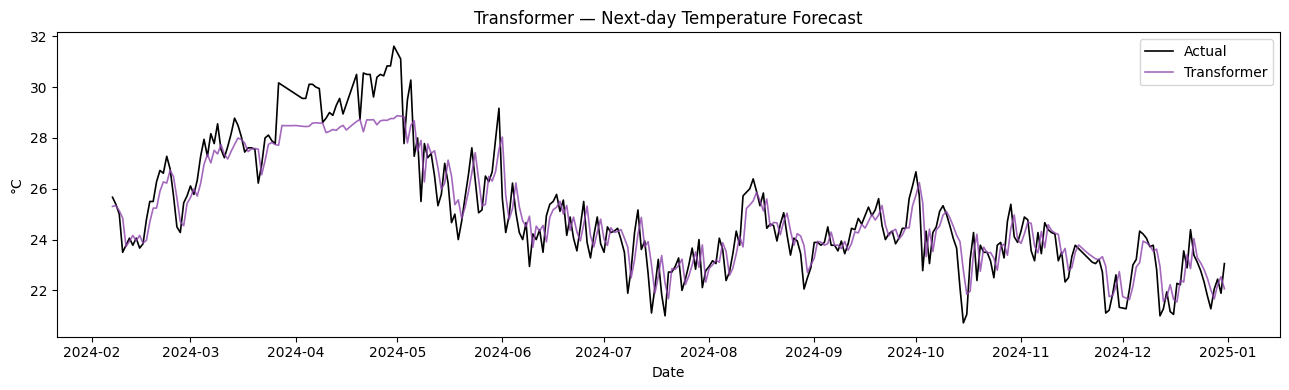

In [18]:
trf=M.TransformerForecaster(d_model=32,nhead=4,layers=2,ff=64,dropout=0.1)
trf,tv,ttt=M.train_model(trf,Xtr,ytr,Xva,yva,epochs=15,patience=3)
with torch.no_grad(): pt=inv(trf(torch.tensor(Xte,dtype=torch.float32)).numpy())
trf_res={'mae':M.mae(yo,pt),'rmse':M.rmse(yo,pt),'train_time':ttt}
print('Transformer  MAE %.3f  RMSE %.3f  (%.1fs)'%(trf_res['mae'],trf_res['rmse'],ttt))
plt.figure(figsize=(13,4)); plt.plot(test_dates,yo,color='black',lw=1.2,label='Actual')
plt.plot(test_dates,pt,color='#8e44ad',lw=1.2,alpha=0.8,label='Transformer')
plt.title('Transformer — Next-day Temperature Forecast'); plt.xlabel('Date'); plt.ylabel('°C')
plt.legend(); plt.tight_layout(); plt.show()

## 13. Model Comparison

In [19]:
comp=pd.DataFrame([
    {'Model':'Persistence','MAE':base['mae'],'RMSE':base['rmse'],'Train time (s)':0.0},
    {'Model':'LSTM','MAE':lstm_res['mae'],'RMSE':lstm_res['rmse'],'Train time (s)':lstm_res['train_time']},
    {'Model':'Transformer','MAE':trf_res['mae'],'RMSE':trf_res['rmse'],'Train time (s)':trf_res['train_time']},
]).round(3)
display(comp)
best=comp.loc[comp['RMSE'].idxmin(),'Model']; print('Best (lowest RMSE):', best)

,Model,MAE,RMSE,Train time (s)
0,Persistence,0.674,0.888,0.000
1,LSTM,0.766,0.972,5.116
2,Transformer,0.736,0.944,11.341


Best (lowest RMSE): Persistence


*Persistence is best on MAE and RMSE; Transformer edges LSTM. With lag-1 autocorrelation 0.92, yesterday's value is a near-optimal one-step predictor, so small untuned neural nets do not beat it. Differences among models are small and not claimed significant.*

## 14. Limitations
Six years is short for climate-trend claims; single-station/local; GSOD daily precipitation has substantial documented missingness; models intentionally tiny/untuned (CPU/battery); the t+1 horizon strongly favours persistence.

## 15. Conclusion
Bengaluru daily temperature (2019–2024) is a **stationary, strongly seasonal, highly persistent** series with a weak warming trend; precipitation is intermittent and seasonal only in aggregate. Statistical evidence (STL, ADF/KPSS, ACF/PACF) is internally consistent. For one-step forecasting the naive persistence baseline is strongest — an honest result given the 0.92 lag-1 autocorrelation.